# HONDA SALES DATA ANALISES


In [2]:
import pandas as pd
import numpy as np 
import jinja2 as j2

# from pandas-profiling import ProfileReport 
import matplotlib.pyplot as plt  
import seaborn as sns  


df = pd.read_csv('Honda All Dataset.csv')
print(df)

      Order_ID  Order_Date  Year  MonthIndex     Month Quarter          State  \
0     ORD00001  30-06-2026  2026           6      June      Q2        Gujarat   
1     ORD00002  15-01-2025  2025           1   January      Q1        Gujarat   
2     ORD00003  20-07-2026  2026           7      July      Q3          Delhi   
3     ORD00004  06-05-2026  2026           5       May      Q2    Maharashtra   
4     ORD00005  23-11-2025  2025          11  November      Q4  Uttar Pradesh   
...        ...         ...   ...         ...       ...     ...            ...   
1495  ORD01496  01-05-2025  2025           5       May      Q2        Gujarat   
1496  ORD01497  22-05-2026  2026           5       May      Q2          Delhi   
1497  ORD01498  16-07-2025  2025           7      July      Q3          Delhi   
1498  ORD01499  14-11-2026  2026          11  November      Q4    Maharashtra   
1499  ORD01500  19-12-2026  2026          12  December      Q4          Delhi   

           City            

In [3]:
df.head()


,Order_ID,Order_Date,Year,MonthIndex,Month,Quarter,State,City,Dealer_Name,Sales_Channel,...,Discount,Insurance_Amount,Accessories_Amount,Finance_Amount,Exchange_Bonus,Net_Sales_Amount,Cost_Price,Gross_Profit,Delivery_Days,Customer_Rating
0,ORD00001,30-06-2026,2026,6,June,Q2,Gujarat,Ahmedabad,Honda Dealer Ahmedabad,Corporate Sale,...,4248,3408,5959,89385,282,98752,70286,28466,10,3.7
1,ORD00002,15-01-2025,2025,1,January,Q1,Gujarat,Surat,Honda Dealer Surat,Corporate Sale,...,4165,6848,5632,71022,4372,83502,64631,18871,10,3.7
2,ORD00003,20-07-2026,2026,7,July,Q3,Delhi,New Delhi,Honda Dealer New Delhi,Corporate Sale,...,3628,3476,7948,86328,3323,97752,70208,27544,7,4.7
3,ORD00004,06-05-2026,2026,5,May,Q2,Maharashtra,Pune,Honda Dealer Pune,Corporate Sale,...,5592,3787,9562,0,2396,146429,117282,29147,5,4.9
4,ORD00005,23-11-2025,2025,11,November,Q4,Uttar Pradesh,Lucknow,Honda Dealer Lucknow,Online Booking,...,2850,6951,7719,86615,1289,101285,69400,31885,10,4.9


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order_ID            1500 non-null   str    
 1   Order_Date          1500 non-null   str    
 2   Year                1500 non-null   int64  
 3   MonthIndex          1500 non-null   int64  
 4   Month               1500 non-null   str    
 5   Quarter             1500 non-null   str    
 6   State               1500 non-null   str    
 7   City                1500 non-null   str    
 8   Dealer_Name         1500 non-null   str    
 9   Sales_Channel       1500 non-null   str    
 10  Bike_Model          1500 non-null   str    
 11  Bike_Segment        1500 non-null   str    
 12  Engine_CC           1500 non-null   int64  
 13  Color               1500 non-null   str    
 14  Customer_Age        1500 non-null   int64  
 15  Customer_Gender     1500 non-null   str    
 16  Payment_Mode     

In [5]:
df.isnull().sum()

Order_ID              0
Order_Date            0
Year                  0
MonthIndex            0
Month                 0
Quarter               0
State                 0
City                  0
Dealer_Name           0
Sales_Channel         0
Bike_Model            0
Bike_Segment          0
Engine_CC             0
Color                 0
Customer_Age          0
Customer_Gender       0
Payment_Mode          0
On_Road_Price         0
Discount              0
Insurance_Amount      0
Accessories_Amount    0
Finance_Amount        0
Exchange_Bonus        0
Net_Sales_Amount      0
Cost_Price            0
Gross_Profit          0
Delivery_Days         0
Customer_Rating       0
dtype: int64

In [6]:
df.describe()


,Year,MonthIndex,Engine_CC,Customer_Age,On_Road_Price,Discount,Insurance_Amount,Accessories_Amount,Finance_Amount,Exchange_Bonus,Net_Sales_Amount,Cost_Price,Gross_Profit,Delivery_Days,Customer_Rating
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,2025.489333,6.526667,174.862667,37.440000,120049.520667,3467.424667,5502.454000,5538.352000,68942.203333,2571.996000,125050.906000,95219.932667,29830.973333,8.017333,4.262867
std,0.500053,3.420295,80.420583,10.354027,45078.330909,1997.710935,1458.269921,2618.650939,66772.708693,1467.635568,45425.972796,36252.956157,10852.225221,4.296511,0.439875
min,2025.000000,1.000000,110.000000,20.000000,77095.000000,7.000000,3000.000000,1001.000000,0.000000,6.000000,74640.000000,60007.000000,6231.000000,1.000000,3.500000
25%,2025.000000,4.000000,125.000000,29.000000,86512.250000,1747.500000,4216.500000,3305.000000,0.000000,1294.250000,91175.250000,68121.500000,22075.750000,4.000000,3.900000
50%,2025.000000,6.500000,125.000000,37.000000,94705.000000,3399.000000,5490.500000,5580.000000,78006.000000,2682.000000,104788.500000,76322.000000,27287.000000,8.000000,4.300000
75%,2026.000000,9.000000,184.000000,46.250000,140745.750000,5261.500000,6773.750000,7797.000000,105369.250000,3869.500000,145976.750000,111505.250000,35444.750000,12.000000,4.700000
max,2026.000000,12.000000,348.000000,55.000000,214986.000000,6991.000000,8000.000000,10000.000000,213560.000000,4997.000000,226874.000000,178486.000000,67845.000000,15.000000,5.000000


# Top selling bike models

In [7]:
# Count the number of sales for each specific Bike Model and show the top 10
top_models_volume = df['Bike_Model'].value_counts().head(10)

print("Top 10 Most Sold Bike Models (by Units):")
print(top_models_volume)


Top 10 Most Sold Bike Models (by Units):
Bike_Model
SP 125        280
Hornet 2.0    256
Shine 125     246
CB350         245
Unicorn       243
Activa 6G     230
Name: count, dtype: int64


/var/folders/vl/z6bk4qhs28984lj_kznpqf180000gn/T/ipykernel_17003/3361620411.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_models_volume.values, y=top_models_volume.index, palette="Reds_r")


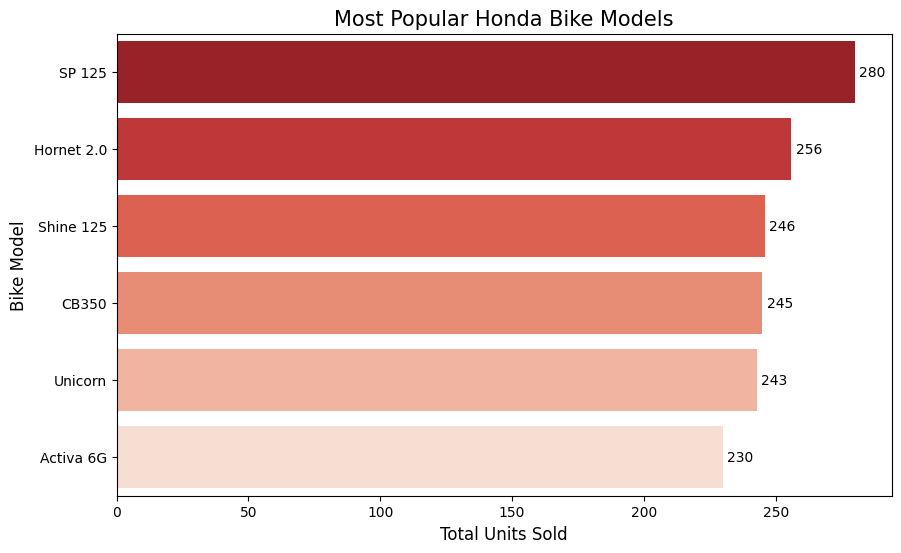

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot the volume numbers using a nice red color palette
ax = sns.barplot(x=top_models_volume.values, y=top_models_volume.index, palette="Reds_r")

plt.title("Most Popular Honda Bike Models", fontsize=15)
plt.xlabel("Total Units Sold", fontsize=12)
plt.ylabel("Bike Model", fontsize=12)

# Add numeric labels to the end of the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()


# Sales_Channel Analsis

In [9]:
prefer_Sales_Channel=df['Sales_Channel'].value_counts()
print(prefer_Sales_Channel)

Sales_Channel
Corporate Sale      504
Online Booking      504
Showroom Walk-in    492
Name: count, dtype: int64


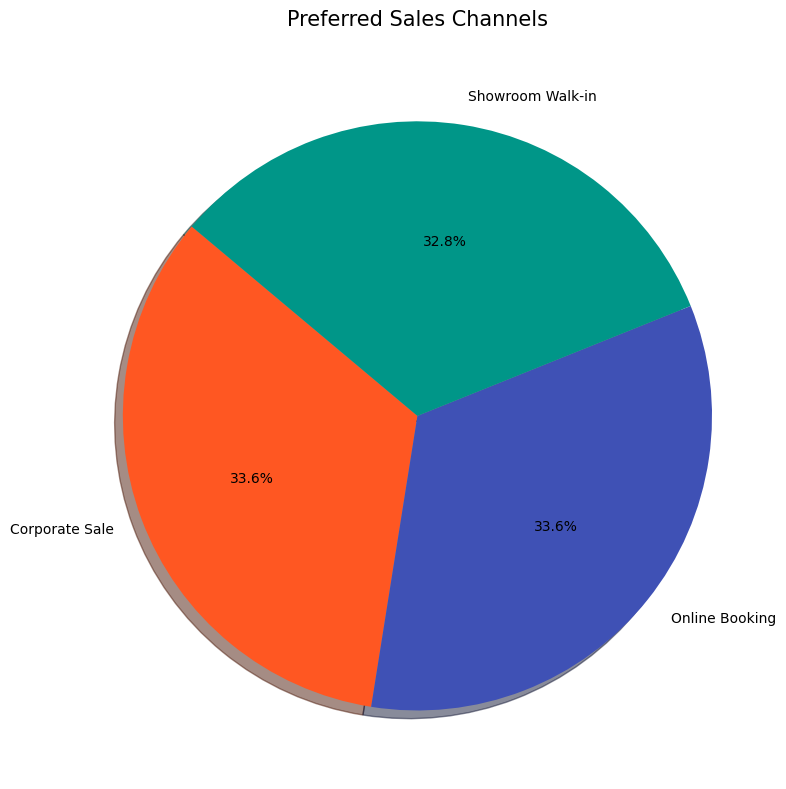

In [10]:
plt.figure(figsize=(8, 8))

# Defining the explosion offset (we use the index length to calculate how many slices to pull out)
explode_effect = [0.05] * len(prefer_Sales_Channel) 

# Plotting the pie chart
plt.pie(prefer_Sales_Channel, 
        labels=prefer_Sales_Channel.index,   # The names of the sales channels
        autopct='%1.1f%%',                   # Automatically calculates and formats percentages
        startangle=140, 
        colors=['#FF5722', '#3F51B5', '#009688', '#FFC107', '#E91E63'][:len(prefer_Sales_Channel)], 
        shadow=True)

# Adding a clean title
plt.title('Preferred Sales Channels', fontsize=15, pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a perfect circle.

# Show the plot
plt.tight_layout()
plt.show()


# Gender-wise purchases Analysis

In [11]:

# Analysis of Gender-wise purchases
gender_purchases = df['Customer_Gender'].value_counts()
print("Gender-wise Purchase Counts:")
print(gender_purchases)

total_costomer= df[df['Customer_Gender'].isin(['Male', 'Female'])]['Customer_Gender'].count()
print(f"total_costomer=",total_costomer)







Gender-wise Purchase Counts:
Customer_Gender
Female    773
Male      727
Name: count, dtype: int64
total_costomer= 1500


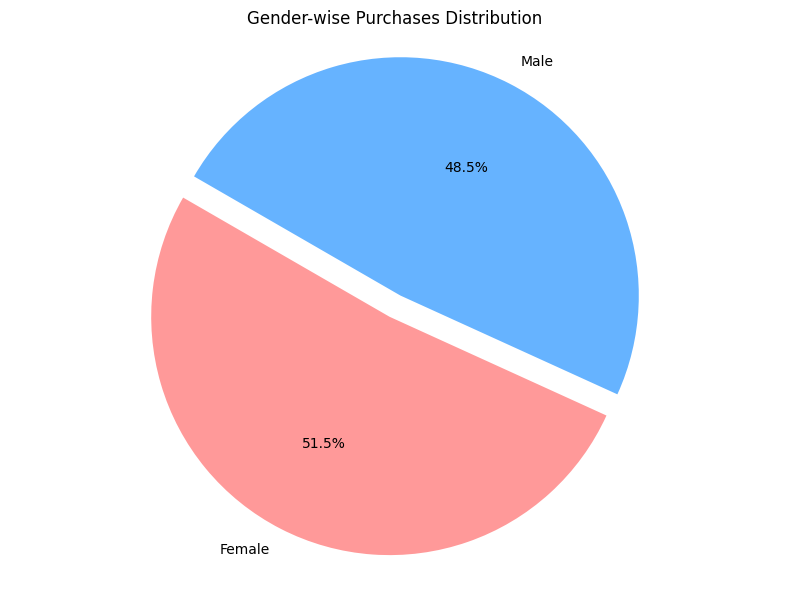

In [12]:

# Pie chart visualization
plt.figure(figsize=(8, 6))

# Plotting the pie chart
plt.pie(gender_purchases, 
        labels=gender_purchases.index, 
        autopct='%1.1f%%', 
        colors=[ '#ff9999','#66b3ff', '#99ff99'], 
        startangle=150, 
        explode=[0.05] * len(gender_purchases) # slightly pull out slices
        ) 

plt.title('Gender-wise Purchases Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the plot
plt.tight_layout()
plt.show()

# Analysis Preferred payment methods

In [13]:
import pandas as pd

# Calculate the frequency of each payment method
payment_methods = df['Payment_Mode'].value_counts()

print("Preferred Payment Methods by costomer:")
print(payment_methods)


Preferred Payment Methods by costomer:
Payment_Mode
Cash           417
Credit Card    379
UPI            366
Finance        338
Name: count, dtype: int64


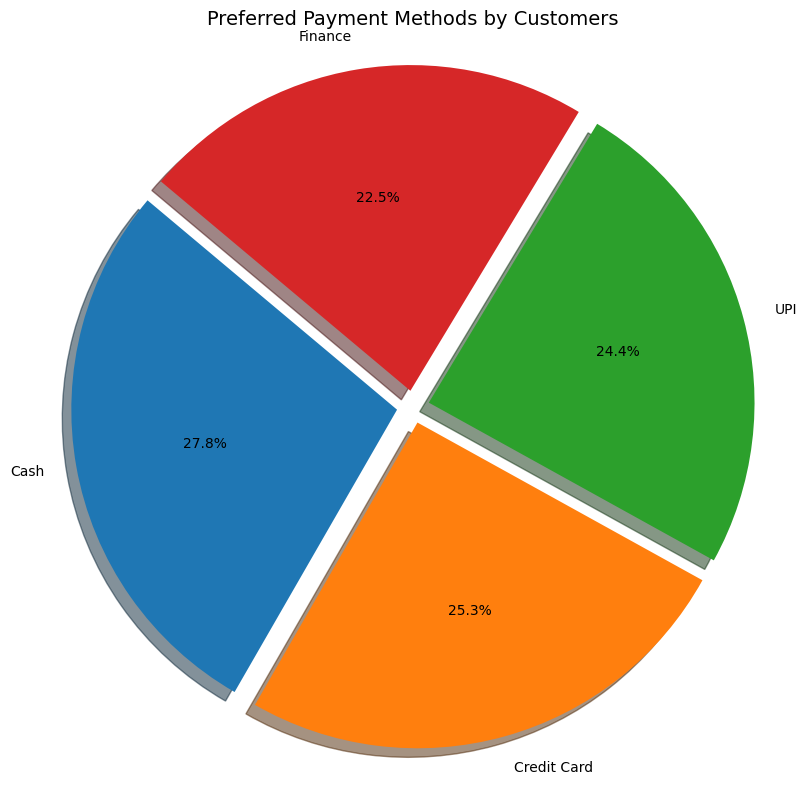

In [14]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 8))

# Define an explosion array to slightly separate the slices (adjusting based on how many methods there are)
explode_effect = [0.05] * len(payment_methods) 

plt.pie(payment_methods, 
        labels=payment_methods.index, 
        autopct='%1.1f%%', 
        startangle=140,
        explode=explode_effect,
        shadow=True)

plt.title('Preferred Payment Methods by Customers', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the plot
plt.tight_layout()
plt.show()


# ＃Relation between Delivery days vs customer rating

In [15]:
import pandas as pd



# removing missing values in these columns
analysis_df = df[['Delivery_Days', 'Customer_Rating']].dropna()

# 1. Calculate Average Custom Rating for each Delivery Day
avg_rating_per_day = analysis_df.groupby('Delivery_Days')['Customer_Rating'].mean().reset_index()
print("Average Customer Rating by Delivery Days:")
print(avg_rating_per_day)

print('🌟Conclusion: Delivery days do not seem to negatively impact customer ratings significantly.')


Average Customer Rating by Delivery Days:
    Delivery_Days  Customer_Rating
0               1         4.213889
1               2         4.216049
2               3         4.314000
3               4         4.238889
4               5         4.294595
5               6         4.218391
6               7         4.323000
7               8         4.228421
8               9         4.294624
9              10         4.234951
10             11         4.285714
11             12         4.323585
12             13         4.253922
13             14         4.200000
14             15         4.280000
🌟Conclusion: Delivery days do not seem to negatively impact customer ratings significantly.


# Age distribution of costomer 

we can use this data for tagated add for the age grouop.

In [16]:
import pandas as pd

# drop any missing values to prevent errors
age_data = df['Customer_Age'].dropna()

# Define the age "bins" (e.g., ages 18-25, 26-35, 36-45...)
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

# Create a new column categorizing each customer into their respective age group
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=True)

# Count how many customers fall into each age group
age_distribution = df['Age_Group'].value_counts().sort_index()

print("Customer Age Distribution (Market Size by Group):")
print(age_distribution)

# Identify the largest market
largest_group = age_distribution.idxmax()
print(f"\n--> The largest market is the '{largest_group}' age group, with {age_distribution.max()} customers.")


Customer Age Distribution (Market Size by Group):
Age_Group
18-25    246
26-35    422
36-45    420
46-55    412
56-65      0
65+        0
Name: count, dtype: int64

--> The largest market is the '26-35' age group, with 422 customers.


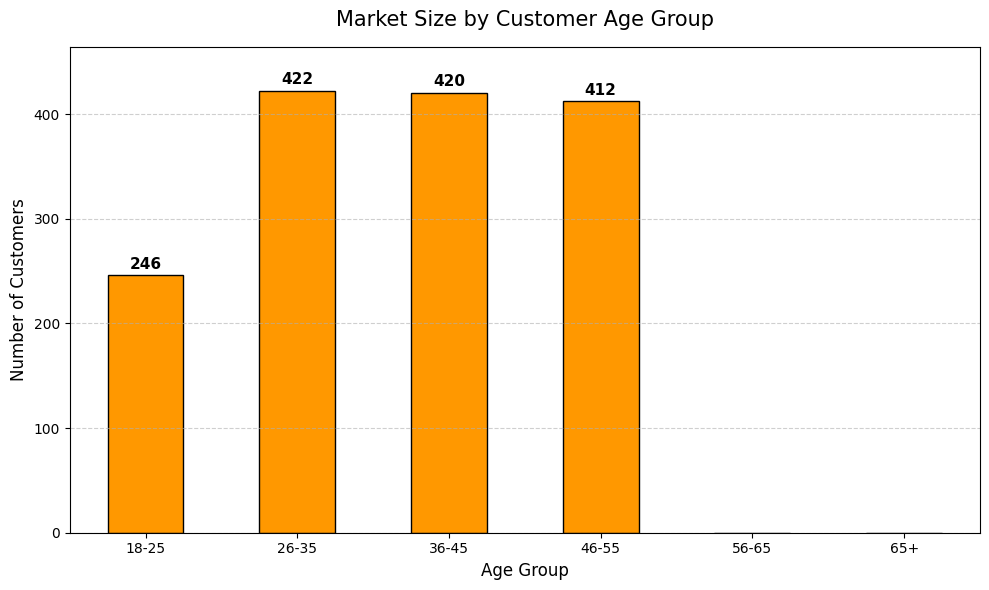

In [17]:
from matplotlib.pyplot import margins
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

#-----------------------------------------
ax = age_distribution.plot(
    kind='bar', 
    color='#FF9800', 
    edgecolor='black'
)

# 2. Add the exact numbers on top of each bar
for p in ax.patches:
    # get_height() gets the exact number for that bar
    value = int(p.get_height()) 
    
    # Only write the number if it's greater than 0
    if value > 0:
        ax.annotate(str(value), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), # Position (center x, top y)
                    ha='center', va='center', 
                    xytext=(0, 8),          # Shift the text 8 points up
                    textcoords='offset points',
                    fontsize=11, fontweight='bold', color='black')

# Adding titles and labels
plt.title('Market Size by Customer Age Group', fontsize=15, pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Make the x-axis labels horizontal and clear
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 3. Slightly increase the very top of the y-axis so the numbers don't get cut off
plt.ylim(0, age_distribution.max() * 1.1)

plt.tight_layout()
plt.show()


# Analysis of which age group gives the maximum total profit.

In [18]:
import pandas as pd

# Group by the Age_Group column and calculate the sum of Gross_Profit
age_profit = df.groupby('Age_Group')['Gross_Profit'].sum()

# Sort the values from highest profit to lowest
age_profit_sorted = age_profit.sort_values(ascending=False)

print("Total Profit Generated by Each Age Group:")
print(age_profit_sorted.apply(lambda x: f"₹ {x:,.2f}"))  # Formatted as currency

# Identify the most profitable group
max_profit_group = age_profit_sorted.idxmax()
print(f"\n--> The '{max_profit_group}' age group gives the maximum profit!")


Total Profit Generated by Each Age Group:
Age_Group
46-55    ₹ 12,565,097.00
26-35    ₹ 12,559,499.00
36-45    ₹ 12,430,677.00
18-25     ₹ 7,191,187.00
Name: Gross_Profit, dtype: str

--> The '46-55' age group gives the maximum profit!


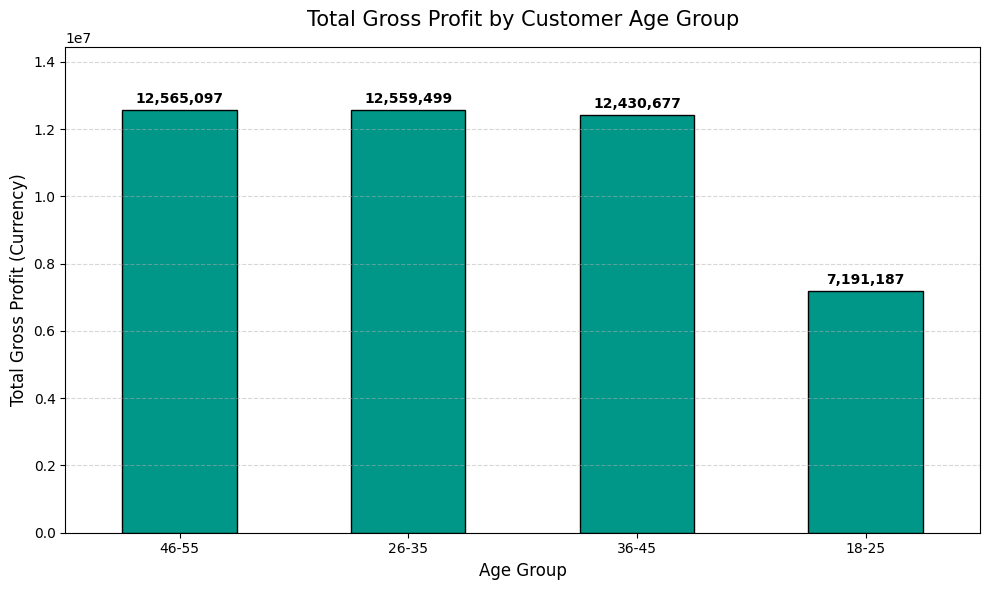

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotting the bar chart
ax = age_profit_sorted.plot(
    kind='bar', 
    color='#009688',  # A nice green color to represent profit
    edgecolor='black'
)

# Add exact numbers above each bar
for p in ax.patches:
    value = p.get_height()
    
    if value > 0:
        # Formats the number down to the thousand/million if needed, or just prints raw value
        ax.annotate(f"{int(value):,}",  # The comma formatting adds commas for readability (e.g. 1,000,000)
                    (p.get_x() + p.get_width() / 2., value), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='black')

# Adding titles and labels
plt.title('Total Gross Profit by Customer Age Group', fontsize=15, pad=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Total Gross Profit (Currency)', fontsize=12)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Keep the top margin clear for the text annotations
plt.ylim(0, age_profit_sorted.max() * 1.15)

plt.tight_layout()
plt.show()
